In [ ]:
import sys
import numpy as np
import copy
from PIL import Image
import cv2
import open3d as o3d
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_control import realsense_wrapper as real

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from force_prediction_prompts import initial_prompt, feedback_prompt
from magpie_prompts.prompts import sf_force_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, create_image_message, send_message
from magpie_prompts.prompts import sf_grasp_selection
import importlib
importlib.reload(sf_force_thinker)
importlib.reload(conversation)
importlib.reload(sf_grasp_selection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2
from magpie_perception import pcd

from PIL import Image
import matplotlib
import matplotlib.pyplot as plt

from magpie_control import ur5

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-04 14:55:30.067852: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-04 14:55:30.067877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-04 14:55:30.068884: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 14:55:30.074528: I te

In [3]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


In [90]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

In [88]:
pcd_wrist2, rgbd_wrist2 = wrist.getPCD()
img_wrist2 = np.array(rgbd_wrist2.color)


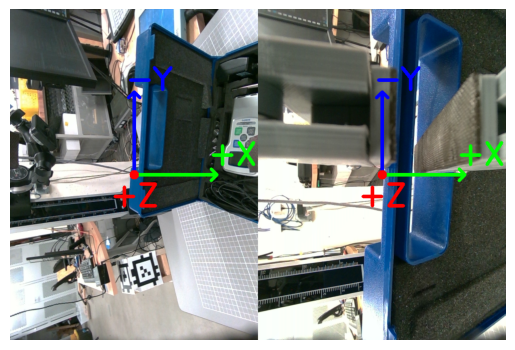

In [92]:
def label_wrist_image(wrist_img):
    '''
    labels wrist image with overlaid x,y,z axes in line with F/T sensor
    '''
    h, w, c = wrist_img.shape

    x_color = (0, 255, 0) # green
    y_color = (0, 0, 255) # blue
    z_color = (255, 0, 0) # red

    # Define axis line lengths (adjust as needed)
    axis_length = min(w, h) // 3

    # Calculate starting point for axes (center of the image)
    center_x, center_y = w // 2, h // 2

    # Draw X-axis
    cv2.arrowedLine(wrist_img, (center_x, center_y), (center_x + axis_length, center_y), x_color, 6)
    cv2.putText(wrist_img, "+X", (center_x + axis_length - 15, center_y -20), cv2.FONT_HERSHEY_SIMPLEX, 2, x_color, 6)

    # Draw Y-axis
    cv2.arrowedLine(wrist_img, (center_x, center_y), (center_x, center_y - axis_length), y_color, 6)
    cv2.putText(wrist_img, "-Y", (center_x - 15, center_y - axis_length - 5), cv2.FONT_HERSHEY_SIMPLEX, 2, y_color, 6)

    # Draw Z-axis (pointing towards the viewer, represented as a circle)
    cv2.circle(wrist_img, (center_x, center_y), 9, z_color, -1)  # Filled circle
    cv2.putText(wrist_img, "+Z", (center_x - 45, center_y + 60), cv2.FONT_HERSHEY_SIMPLEX, 2, z_color, 6)

    return wrist_img

# pcd_wrist, rgbd_wrist = wrist.getPCD()
# pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

# img_wrist = np.array(rgbd_wrist.color)
# img_wkspc = np.array(rgbd_wkspc.color)

img_wrist_rotated = cv2.rotate(img_wrist, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(img_wrist_rotated.copy()) # Use .copy() to avoid modifying the original
img_wrist2_rotated = cv2.rotate(img_wrist2, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img2_labeled = label_wrist_image(img_wrist2_rotated.copy()) # Use .copy() to avoid modifying the original
# img_wkspc_resized = cv2.resize(img_wkspc, (img_wrist_rotated.shape[1], img_wrist_rotated.shape[0]))
import imutils
img_wkspc_resized = imutils.resize(img_wkspc, height=img_wrist_rotated.shape[0])
# final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))
final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = "axes7_double_wrist.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [95]:
user_query = "close the blue case"
# user_query = "grab the scissors"
# user_query = "grab the screwdriver"
# user_query = "open the box"
# user_query = "close the box"

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)

grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)

case lid handle


[(array([238.838, 364.939, 567.937, 416.065], dtype=float32), 0), (array([204.187, 221.807, 638.836, 410.578], dtype=float32), 0), (array([311.22 ,  27.598, 358.212,  67.732], dtype=float32), 0), (array([  9.639, 371.189, 638.446, 479.12 ], dtype=float32), 0), (array([369.022,  28.822, 415.507,  65.741], dtype=float32), 0), (array([312.93 ,  26.788, 414.218,  68.66 ], dtype=float32), 0), (array([  3.082, 246.153, 638.654, 480.258], dtype=float32), 0), (array([202.41 , 365.911, 639.676, 458.99 ], dtype=float32), 0), (array([337.118,  34.854, 359.1  ,  67.422], dtype=float32), 0), (array([147.513, 153.954, 647.937, 410.915], dtype=float32), 0), (array([508.825,  24.62 , 575.9  ,  49.773], dtype=float32), 0), (array([3.308e+02, 5.951e-02, 4.163e+02, 3.096e+01], dtype=float32), 0), (array([239.381, 365.567, 354.876, 404.337], dtype=float32), 0), (array([384.292,  95.604, 428.061, 121.358], dtype=float32), 0), (array([562.219,  61.464, 636.516, 126.728], dtype=float32), 0), (array([  3.688,

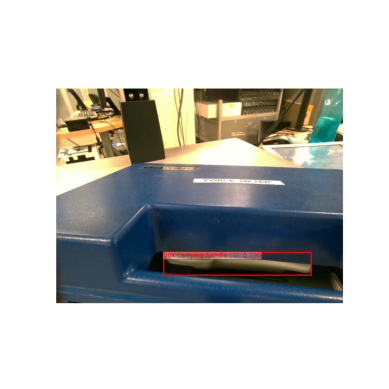

In [36]:
query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
import importlib
importlib.reload(pcd)
pred_image = None

def find_object(rgbd_img, label_model, mask_model, seg_type, wrist_camera):
    img = np.array(rgbd_img.color)
    label_model.TOP_K = 1
    label_model.label(img, query, query, topk=True, plot=False)
    index = 0
    boxes = []
    if seg_type == "box-dbscan":
        boxes = label_model.sorted_labeled_boxes_coords
        pred_image = label_model.preds_plot
    elif seg_type == "mask":
        mask_sam2 = mask_model
        mask_sam2.set_image_and_labels(np.array(rgbd_img.color), 
                                        label_model.sorted_boxes_coords, 
                                        label_model.sorted_labels)
        masks = mask_sam2.get_masks(label_model.sorted_labels)
        mask_sam2.plot_image(rgbd_img.color, masks[:3], 
                                label_model.sorted_boxes_coords[:3],
                                label_model.sorted_scores, show_plot=False)
        pred_image = mask_sam2.pred_image
        boxes = masks.astype(bool)
    print(boxes)
    print(type(rgbd_img))
    _, ptcld, GOAL_POSE, _ = pcd.get_segment(boxes, 
                                        index, 
                                        rgbd_img, 
                                        wrist_camera, 
                                        type=seg_type, 
                                    #  type="box", 
                                    #  method="quat", 
                                        method="iterative", 
                                        display=False)
    
    return GOAL_POSE, pred_image

pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, label_model, mask_model, seg_type, wrist)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [ ]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False)
robot.start()
robot.moveL_translation_tooltip(pose, asynch=False)
robot.stop()

In [ ]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.open('scalingforce/axes7_double_wrist.png').convert("RGB")

# obj = "small servo motor"
prompt_config = {
"obj": grasp_phrase,
"task": user_query
}
# obj = "small servo motor"
# prompt_config = {
# "obj": "small servo motor",
# "task": f"slide the {obj} rapidly up the table for 10 cm"
# }

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = create_image_message(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)

